#**Fuzzy sistem za procjenu rizika od mentalnih poteškoća kod studenata**


---
##1. Opis problema i konteksta primjene fuzzy logike
---

Kaggle. (2025.) Student Mental Health Survey. Dostupno na: https://www.kaggle.com/datasets/abdullahashfaqvirk/student-mental-health-survey/data

⚠️ Napomena za pokretanje: Ovaj notebook je pisan za Google Colab. Prilikom pokretanja, potrebno je ručno učitati MentalHealthSurvey.csv dataset sa Kaggle-a kada se aktivira files.upload() ćelija.

Mentalno zdravlje podrazumijeva stanje psihološke stabilnosti koje omogućava pojedincima da se nose sa svakodnevnim stresom, ostvaruju svoje potencijale, produktivno funkcionišu i doprinose zajednici. Kod studenata, očuvanje mentalnog zdravlja postaje sve važnije s obzirom na svakodnevne izazove poput akademskog pritiska, finansijskih briga i društvenih očekivanja. Ova tema predstavlja iznimnu važnost imajući u vidu to da se većina ljudi upravo u studentskom periodu života prvi put suočava sa izazovima mentalnog zdravlja, ali i također da je to "tabu" tema naše svakodnevnice.

Problem je složen jer faktori koji utiču na mentalno zdravlje nisu samo brojčano mjerljivi, često su subjektivni, međusobno zavisni i promjenjivi. Tradicionalne metode evaluacije često nisu dovoljne za dobijanje potpune slike. U okviru ovog projekta koristili smo fuzzy logiku. Fuzzy logika je odabrana zbog svoje sposobnosti da se nosi s nepreciznim i subjektivnim informacijama, čime omogućava predstavljanje realnih životnih situacija koje se ne mogu jednostavno numerički predstaviti. Korišten je stvarni dataset koji obuhvata različite aspekte studentskog života — od kvaliteta sna, osjećaja izolacije i nivoa anksioznosti, do akademskog pritiska, finansijskih briga i zadovoljstva studijama.


---
##2. Definicija ulaznih i izlaznih varijabli
---

U ovom radu bavimo se analizom faktora koji utiču na mentalno zdravlje studenata koristeći fuzzy logiku. Da bismo to postigli, prvo smo definisali ulazne i izlazne varijable koje su važne za procjenu rizika od problema sa mentalnim zdravljem. Varijable su izabrane na osnovu stvarnih podataka prikupljenih anketom, a svaki odabrani faktor ima logičku vezu s ukupnim psihičkim stanjem pojedinca.

Jedna od prvih varijabli koje smo obradili jeste average_sleep, koja predstavlja prosječan broj sati sna pojedinca. Znamo da je san ključan za oporavak tijela i psihe, pa smatramo da manjak sna može povećati rizik od anksioznosti, depresije, i drugih poteškoća. Vrijednosti ove varijable bile su tekstualno izražene kao “2-4 hrs”, “4-6 hrs”, pa smo ih pretvorili u numeričke srednje vrijednosti kako bi bile pogodne za analizu.

Zatim imamo financial_concerns, odnosno finansijske brige. Studenti često osjećaju pritisak zbog troškova studiranja, života i mogućeg zaduženja, pa se ova varijabla direktno odražava na nivo stresa. Veće vrijednosti označavaju veći stepen brige, a skalirane su u rasponu od 0 do 10.

Sličnu ulogu ima i varijabla future_insecurity, koja opisuje koliko je osoba zabrinuta zbog svoje budućnosti – karijere, zapošljavanja i opšte sigurnosti. U vremenu neizvjesnosti, ova nesigurnost može značajno uticati na mentalno stanje, zato je uključena kao važan ulaz.

Isolation, odnosno osjećaj izolovanosti, također je jedna od ključnih varijabli. Osobe koje su usamljene i bez podrške, češće imaju problema s mentalnim zdravljem. Kao i ostale varijable, i ova je numeričkog tipa, skalirana na 0–10.

Varijable anxiety i depression direktno mjere nivoe anksioznosti i depresivnih simptoma, koji su osnovne komponente svakog ozbiljnijeg problema s mentalnim zdravljem. Budući da ih je anketa već mjerila, prepoznate su kao izuzetno relevantni ulazi.

Pažnja je obraćena i na social_relationships – odnose koje osoba ima s drugima. Ova varijabla je važna jer jake i pozitivne društvene veze djeluju kao zaštitni faktor. Pošto se veće vrijednosti u podacima odnose na bolje odnose, preokrenuli smo skalu kako bi veća vrijednost predstavljala veći rizik (tj. lošije odnose), što je u skladu s ostalim varijablama.

Na kraju, tu je i academic_pressure, odnosno pritisak zbog studija. Visoka očekivanja, kratki rokovi i opterećenost učenjem često dovode do iscrpljenosti, pa je ova varijabla uključena kao dodatni faktor stresa.

Sve ulazne varijable su numeričkog tipa, skalirane na opseg od 0 do 10 radi lakše obrade u fuzzy sistemu. Gdje je bilo potrebno, nedostajuće vrijednosti su popunjene prosječnim vrijednostima.

Kao izlaznu varijablu odabrali smo intervention_needed – procjenu potrebe za intervencijom na osnovu odgovarajućih ulaza. Ova varijabla objedinjuje sve prethodne faktore i daje jednu zajedničku mjeru koja može pomoći u prepoznavanju osoba kojima je potrebna podrška. Tip ove varijable je također numerički, gdje veća vrijednost znači veći rizik.


In [ ]:
# Uvoz potrebnih biblioteka i učitavanje podataka
!pip install -q scikit-fuzzy

from google.colab import files
uploaded = files.upload()     # Učitavanje CSV datoteke s lokalnog računara

import pandas as pd
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Učitavanje CSV fajla i uklanjanje nepotrebnih razmaka iz naziva kolona
data = pd.read_csv('MentalHealthSurvey.csv')
data.columns = data.columns.str.strip()

# Odabir relevantnih ulaznih varijabli za analizu
input_variables = data[['average_sleep', 'financial_concerns', 'future_insecurity',
                        'isolation', 'anxiety', 'depression', 'social_relationships',
                        'academic_pressure']].copy()

# Konverzija tekstualnih opisa spavanja u numeričke vrijednosti
def process_sleep(sleep_range):
    if sleep_range == '2-4 hrs':
        return 3         #srednja vrijednost iz opsega
    elif sleep_range == '4-6 hrs':
        return 5
    elif sleep_range == '7-8 hrs':
        return 7.5
    else:
        return np.nan    # nepoznate vrijednosti označene kao NaN

input_variables['average_sleep'] = input_variables['average_sleep'].apply(process_sleep)

# Skaliranje varijabli na zajedničku skalu (0–10) radi ujednačene obrade u fuzzy sistemu
scaler = MinMaxScaler(feature_range=(0, 10))
scale_columns = ['financial_concerns', 'future_insecurity', 'isolation',
                 'anxiety', 'depression', 'social_relationships', 'academic_pressure']
input_variables[scale_columns] = scaler.fit_transform(input_variables[scale_columns])

# Promjena skale za 'social_relationships' (jer je veći broj = bolji odnosi → manje rizika)
input_variables['social_relationships'] = 10 - input_variables['social_relationships']

# Obrada nedostajućih vrijednosti
# Popunjavanje NaN vrijednosti srednjim vrijednostima svake kolone
input_variables = input_variables.fillna(input_variables.mean())

# Ispis obrađenih podataka za provjeru
print("\nPrikaz odabranih ulaznih varijabli:")
print(input_variables.head())

# Spremanje pripremljenih podataka u novi CSV fajl (nije neophodno)
input_variables.to_csv('processed_mental_health_inputs.csv', index=False)

# Informativni pregled svih varijabli koje će se koristiti u fuzzy logici
print("\nOdabrane ulazne varijable za implementaciju fuzzy logike:")
print("- average_sleep: Opseg ~3-7.5 (sati spavanja, skalirano)")
print("- financial_concerns: 0-10 (veća vrijednost = više briga)")
print("- future_insecurity: 0-10 (veća vrijednost = više nesigurnosti)")
print("- isolation: 0-10 (veća vrijednost = više izolacije)")
print("- anxiety: 0-10 (veća vrijednost = više anksioznosti)")
print("- depression: 0-10 (veća vrijednost = više depresije)")
print("- social_relationships: 0-10 (veća vrijednost = bolji odnosi → skalirano obrnuto)")
print("- academic_pressure: 0-10 (veća vrijednost = više akademskog pritiska)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 8.3 MB/s eta 0:00:00


Saving MentalHealthSurvey.csv to MentalHealthSurvey.csv

Prikaz odabranih ulaznih varijabli:
   average_sleep  financial_concerns  future_insecurity  isolation  anxiety  \
0            5.0                 7.5                2.5        0.0      0.0   
1            5.0                 0.0                7.5        5.0      5.0   
2            3.0                 5.0                0.0        5.0      5.0   
3            5.0                 7.5                5.0       10.0     10.0   
4            5.0                 2.5                7.5        7.5     10.0   

   depression  social_relationships  academic_pressure  
0         2.5                   5.0               10.0  
1         5.0                   5.0                7.5  
2         2.5                   2.5               10.0  
3        10.0                  10.0                7.5  
4        10.0                   5.0               10.0  

Odabrane ulazne varijable za implementaciju fuzzy logike:
- average_sleep: Opseg ~3-7.5 (

---
##3. Definiranje fuzzy skupova
---

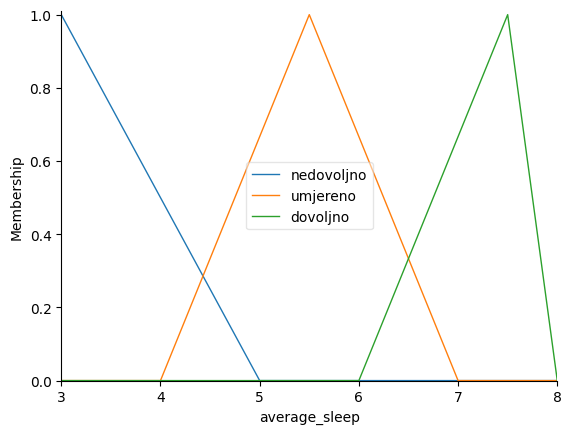

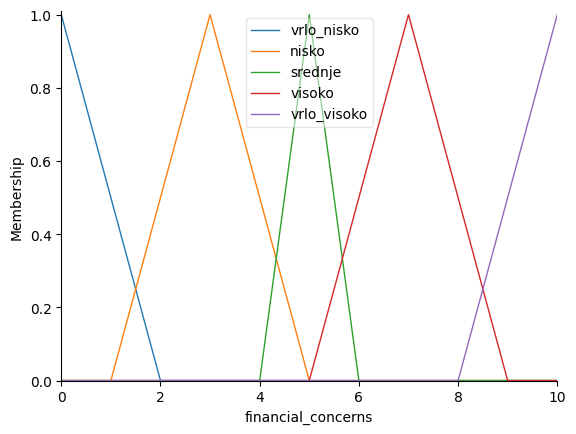

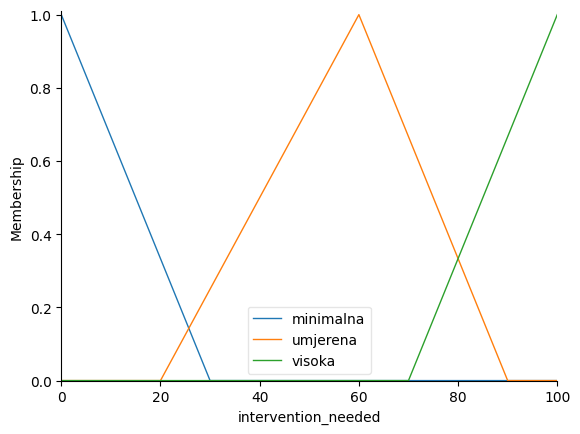

In [ ]:
# Uvoz biblioteka
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Definicija domena za sve varijable
average_sleep = ctrl.Antecedent(np.arange(3, 8.1, 0.1), 'average_sleep')
financial_concerns = ctrl.Antecedent(np.arange(0, 11, 1), 'financial_concerns')
future_insecurity = ctrl.Antecedent(np.arange(0, 11, 1), 'future_insecurity')
isolation = ctrl.Antecedent(np.arange(0, 11, 1), 'isolation')
anxiety = ctrl.Antecedent(np.arange(0, 11, 1), 'anxiety')
depression = ctrl.Antecedent(np.arange(0, 11, 1), 'depression')
social_relationships = ctrl.Antecedent(np.arange(0, 11, 1), 'social_relationships')
academic_pressure = ctrl.Antecedent(np.arange(0, 11, 1), 'academic_pressure')
intervention_needed = ctrl.Consequent(np.arange(0, 101, 1), 'intervention_needed')

# Funkcije pripadnosti
average_sleep['nedovoljno'] = fuzz.trimf(average_sleep.universe, [3, 3, 5])
average_sleep['umjereno'] = fuzz.trimf(average_sleep.universe, [4, 5.5, 7])
average_sleep['dovoljno'] = fuzz.trimf(average_sleep.universe, [6, 7.5, 8])

social_relationships['losi'] = fuzz.trimf(social_relationships.universe, [0, 0, 5])
social_relationships['umjereni'] = fuzz.trimf(social_relationships.universe, [2, 5, 8])
social_relationships['dobri'] = fuzz.trimf(social_relationships.universe, [5, 10, 10])

for var in [financial_concerns, future_insecurity, isolation, anxiety, depression, academic_pressure]:
    var['vrlo_nisko'] = fuzz.trimf(var.universe, [0, 0, 2])
    var['nisko'] = fuzz.trimf(var.universe, [1, 3, 5])
    var['srednje'] = fuzz.trimf(var.universe, [4, 5, 6])
    var['visoko'] = fuzz.trimf(var.universe, [5, 7, 9])
    var['vrlo_visoko'] = fuzz.trimf(var.universe, [8, 10, 10])

intervention_needed['minimalna'] = fuzz.trimf(intervention_needed.universe, [0, 0, 30])
intervention_needed['umjerena'] = fuzz.trimf(intervention_needed.universe, [20, 60, 90])
intervention_needed['visoka'] = fuzz.trimf(intervention_needed.universe, [70, 100, 100])

# Prikaz grafova funkcija pripadnosti za odabrane varijable
average_sleep.view()
financial_concerns.view()
#future_insecurity.view()
#isolation.view()
#anxiety.view()
#depression.view()
#academic_pressure.view()
#social_relationships.view()
intervention_needed.view()

Grafovi iznad pokazuju ponašanje tzv. *funkcija pripadnosti* za ulazne i izlazne varijable u našem fuzzy sistemu. Svaka od tih funkcija zapravo pokazuje kako neke konkretne brojeve (kao što je broj sati sna ili depresije) možemo povezati sa opisima kao što su “nedovoljno”, “srednje”, “visoko” i slično. Ovo je korisno jer u procjeni mentalnog zdravlja često nemamo precizne podatke, pa nam ovakav način pomaže da bolje razumijemo nejasne ili subjektivne informacije i kasnije ih efikasnije korstimo.

Na prvom grafu vidi se kako ulazna varijabla average_sleep (prosječno spavanje) iz našeg dataseta može, na osnovu svoje numeričke vrijednosti, spadati u kategoriju “nedovoljno”, “umjereno” ili “dovoljno”. Te vrijednosti su prikazane pomoću trouglastih linija koje se preklapaju, pa se tako omogućava postepeni prelaz između tih stanja.

Drugi graf prikazuje koliko je neko zabrinut za finansije (financial_concerns) kroz pet nivoa od “vrlo nisko” do “vrlo visoko”, što fuzzy sistemu daje veću preciznost.

Treći graf prikazuje izlaznu varijablu intervention_needed (potreba za intervencijom), koja može biti minimalna, umjerena ili visoka, u zavisnosti od ulaznih podataka.

Ove grafove smo dodali da bismo što bolje prikazali kako se *konkretne brojčane vrijednosti preslikavaju u određene kategorije* s kojima ćemo kasnije raditi prilikom pravljenja fuzzy pravila. Na taj način, lakše je razumjeti kako sistem iz realnih podataka dolazi do zaključaka koristeći ove definisane kategorije. Ukratko, ove funkcije pomažu sistemu da bolje “razumije” i obradi ne baš precizne informacije, što je važno kad se radi o temama kao što je mentalno zdravlje.


---
##4. Izrada fuzzy pravila
---

In [ ]:
# Pravila
rules = [

    # Visoka intervencija
    ctrl.Rule(anxiety['visoko'] & depression['visoko'], intervention_needed['visoka']),
    ctrl.Rule(isolation['visoko'] & social_relationships['losi'], intervention_needed['visoka']),
    ctrl.Rule(average_sleep['nedovoljno'] & academic_pressure['visoko'], intervention_needed['visoka']),
    ctrl.Rule(anxiety['vrlo_visoko'] | depression['vrlo_visoko'], intervention_needed['visoka']),
    ctrl.Rule(future_insecurity['vrlo_visoko'] & financial_concerns['vrlo_visoko'], intervention_needed['visoka']),
    ctrl.Rule(anxiety['visoko'] & ~depression['nisko'] & academic_pressure['visoko'], intervention_needed['visoka']),
    ctrl.Rule(isolation['visoko'] & future_insecurity['visoko'] & average_sleep['nedovoljno'], intervention_needed['visoka']),


    # Umjerena intervencija
    ctrl.Rule(financial_concerns['srednje'] | future_insecurity['srednje'], intervention_needed['umjerena']),
    ctrl.Rule(depression['srednje'] & anxiety['srednje'], intervention_needed['umjerena']),
    ctrl.Rule(social_relationships['umjereni'] & isolation['srednje'], intervention_needed['umjerena']),
    ctrl.Rule(anxiety['visoko'] & academic_pressure['srednje'], intervention_needed['umjerena']),
    ctrl.Rule(isolation['srednje'] & ~future_insecurity['nisko'], intervention_needed['umjerena']),
    ctrl.Rule(average_sleep['umjereno'] & academic_pressure['srednje'], intervention_needed['umjerena']),
    ctrl.Rule(anxiety['srednje'] | depression['srednje'], intervention_needed['umjerena']),


    # Minimalna intervencija
    ctrl.Rule(average_sleep['dovoljno'] & social_relationships['dobri'], intervention_needed['minimalna']),
    ctrl.Rule(anxiety['nisko'] & ~depression['visoko'], intervention_needed['minimalna']),
    ctrl.Rule(academic_pressure['nisko'] & financial_concerns['nisko'], intervention_needed['minimalna']),
    ctrl.Rule(anxiety['vrlo_nisko'] & depression['vrlo_nisko'], intervention_needed['minimalna']),
    ctrl.Rule(
        anxiety['vrlo_nisko'] &
        depression['vrlo_nisko'] &
        academic_pressure['vrlo_nisko'] &
        isolation['vrlo_nisko'] &
        financial_concerns['vrlo_nisko'] &
        future_insecurity['vrlo_nisko'],
        intervention_needed['minimalna']
    ),
    ctrl.Rule(
        average_sleep['dovoljno'] &
        financial_concerns['nisko'] &
        future_insecurity['nisko'] &
        social_relationships['dobri'],
        intervention_needed['minimalna']
    )
]

Da bismo omogućili računanje izlazne varijable intervention_needed pomoću fuzzy logike, definisali smo skup pravila koja opisuju logičke veze između ulaznih varijabli i očekivanog ishoda. Svaka ulazna varijabla je prethodno pretvorena u fuzzy skupove. Na primjer, za varijablu average_sleep formirali smo skupove poput "nedovoljno", "umjereno" i "dovoljno", dok smo za varijable poput anxiety, depression i academic_pressure koristili skupove "vrlo_nisko", "nisko" , "srednje", "visoko" i "vrlo_visoko", u skladu sa skalom od 0 do 10.

Fuzzy pravila su definisana na osnovu kombinacija ovih skupova. Na primjer:
•	Ako je broj sati sna nizak i osjećaj anksioznosti visok, onda je rizik za mentalno zdravlje visok.
•	Ako su socijalni odnosi loši i osjećaj izolovanosti izražen, rizik je takođe visok.
•	Ako je finansijski problemi umjeren i niska je nesigurnost vezana za budućnost, rizik je niži.
•	Ako su osjećaj anksioznosti, depresije i akademskog pritiska svi visoki, tada je ukupni rizik vrlo visok.

U kodu je korišten skfuzzy.control modul iz Python biblioteke scikit-fuzzy, kojim su pravila implementirana kroz ctrl.Rule() funkcije. Svako pravilo povezuje konkretne ulazne skupove s odgovarajućim izlaznim skupom (minimalna, umjerena i visoka potreba za intervencijom). Nakon što se pravila definišu, kreira se kontrolni sistem koji omogućava donošenje odluka na osnovu stvarnih vrijednosti koje ulazne varijable uzimaju.

Broj pravila nije prevelik, kako bi sistem ostao jednostavan i razumljiv, ali je dovoljan da obuhvati najvažnije kombinacije faktora koje najčešće utiču na mentalno zdravlje studenata. U slučaju preklapanja ishod određuje agregacija max-min operacijom, a defuzifikacija se vrši Centroid metodom.

---
##5. Implementacija fuzzy sistema u Phyton-u i prikaz rezultata
---

###Primjer primjene fuzzy sistema za korisnikov unos proizvoljnih varijabli u opsegu

Unesite vrijednosti (0-10 ili 3-8 za spavanje):
Anksioznost (0-10): 7
Depresija (0-10): 7
Prosječan broj sati sna (3-8): 7
Akademski pritisak (0-10): 7
Kvalitet socijalnih odnosa (0-10): 7
Osjećaj izolovanosti (0-10): 7
Finansijske brige (0-10): 7
Nesigurnost u budućnost (0-10): 7

Procijenjena potreba za intervencijom: 59.66/100 



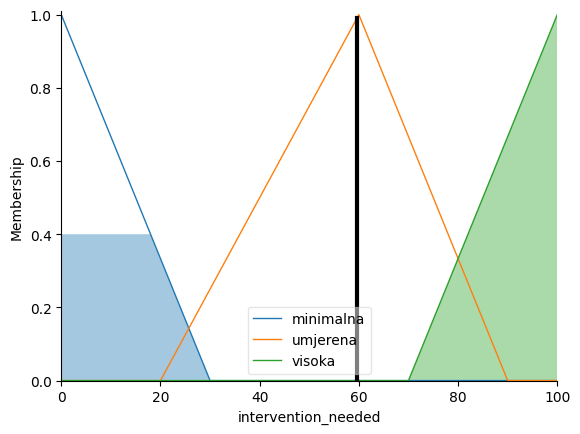

In [ ]:
# Kreiranje kontrolnog sistema i simulacije
intervention_ctrl = ctrl.ControlSystem(rules)
intervention_sim = ctrl.ControlSystemSimulation(intervention_ctrl)

# Funkcija za korisnički unos i evaluaciju
def run_custom_fuzzy_system():
    print("Unesite vrijednosti (0-10 ili 3-8 za spavanje):")

    anxiety_val = float(input("Anksioznost (0-10): "))
    depression_val = float(input("Depresija (0-10): "))
    average_sleep_val = float(input("Prosječan broj sati sna (3-8): "))
    academic_pressure_val = float(input("Akademski pritisak (0-10): "))
    social_relationships_val = float(input("Kvalitet socijalnih odnosa (0-10): "))
    isolation_val = float(input("Osjećaj izolovanosti (0-10): "))
    financial_concerns_val = float(input("Finansijske brige (0-10): "))
    future_insecurity_val = float(input("Nesigurnost u budućnost (0-10): "))

    # Postavljanje ulaznih vrijednosti
    intervention_sim.input['anxiety'] = anxiety_val
    intervention_sim.input['depression'] = depression_val
    intervention_sim.input['average_sleep'] = average_sleep_val
    intervention_sim.input['academic_pressure'] = academic_pressure_val
    intervention_sim.input['social_relationships'] = social_relationships_val
    intervention_sim.input['isolation'] = isolation_val
    intervention_sim.input['financial_concerns'] = financial_concerns_val
    intervention_sim.input['future_insecurity'] = future_insecurity_val

    # Izračun fuzzy izlaza
    intervention_sim.compute()
    rezultat = intervention_sim.output['intervention_needed']
    print(f"\nProcijenjena potreba za intervencijom: {rezultat:.2f}/100 \n")

    # Prikaz grafa pripadnosti
    intervention_needed.view(sim=intervention_sim)

# Pokretanje sistema
intervention_ctrl = ctrl.ControlSystem(rules)
intervention_sim = ctrl.ControlSystemSimulation(intervention_ctrl)
run_custom_fuzzy_system()

Kao dio naše implementacije napravili smo i jedan *interaktivni primjer* koji korisniku daje mogućnost da sam unese vrijednosti za sve prethodno definisane ulazne varijable, kao što su anksioznost, depresija, koliko sati spava, koliko osjeća akademski pritisak, kakav mu je kvalitet odnosa s ljudima oko sebe, da li se osjeća izolovano, koliko ga muče finansijske brige i koliko je nesiguran u budućnost. Kad korisnik unese te podatke, naš fuzzy logički sistem koristi pravila koja smo ranije postavili da izračuna broj između 0 i 100 koji pokazuje koliko je, prema sistemu, potrebna neka vrsta intervencije ili pomoći.

Ovaj primjer smo napravili da pokažemo kako sistem može pomoći u procjeni nečijeg stanja na individualan način, čak i kad su podaci koje dobijemo djelimično subjektivni ili nisu baš precizni. Nakon što se unesu podaci i sistem ih obradi, pojavljuje se graf koji pokazuje fuzzy izlaz, odnosno koliko je ta osoba u svakoj od kategorija: minimalna, umjerena ili visoka potreba za intervencijom. Na grafu se vidi i jedna vertikalna linija koja pokazuje tačan broj koji je sistem izračunao.

Još jedna zanimljiva stvar na takvom grafu su oblici ispod linija funkcija pripadnosti koji su ispunjeni bojom. Oni nam pokazuju kako se ta konkretna vrijednost dijeli između više kategorija. Na primjer, rezultat može biti 60% u kategoriji “umjerena” i 40% u “visoka”. To znači da sistem ne gleda stvari crno-bijelo, nego uzima u obzir da se stanje može nalaziti negdje između dvije kategorije. Ovakav prikaz pomaže da se bolje razumije kako je fuzzy sistem došao do svog zaključka i olakšava tumačenje rezultata.


###Kreiranje fuzzy kontrolnog sistema i pripadajuće simulacije

In [ ]:
# Ovdje se koristi prethodno definisan skup pravila (rules)
intervention_ctrl = ctrl.ControlSystem(rules)
intervention_system = ctrl.ControlSystemSimulation(intervention_ctrl)

# Funkcija za evaluaciju fuzzy sistema za svaki red (studenta) iz dataseta
# Ulaz: dataframe sa svim ulaznim varijablama
# Izlaz: novi dataframe sa ocjenom rizika (intervention_score) i kategorijom (minimalna/umjerena/visoka)
def evaluate_dataset(dataset):
    results = []
    for idx, row in dataset.iterrows():
        # Postavljanje vrijednosti za svaku ulaznu fuzzy varijablu iz reda dataseta
        intervention_system.input['average_sleep'] = row['average_sleep']
        intervention_system.input['financial_concerns'] = row['financial_concerns']
        intervention_system.input['future_insecurity'] = row['future_insecurity']
        intervention_system.input['isolation'] = row['isolation']
        intervention_system.input['anxiety'] = row['anxiety']
        intervention_system.input['depression'] = row['depression']
        intervention_system.input['social_relationships'] = row['social_relationships']
        intervention_system.input['academic_pressure'] = row['academic_pressure']

        # Izračun fuzzy sistema na osnovu ulaza
        intervention_system.compute()
        if 'intervention_needed' in intervention_system.output:
          score = intervention_system.output['intervention_needed']
        else:
          score = 0  # ili neki fallback (npr. 50)


        # Kategorizacija izlaza na osnovu opsega vrijednosti
        if score <= 30:
            category = 'minimalna'
        elif score <= 70:
            category = 'umjerena'
        else:
            category = 'visoka'

        # Spremanje rezultata u listu kao rječnik
        results.append({'student_id': idx, 'intervention_score': score, 'intervention_category': category})

    # Pretvaranje liste rezultata u DataFrame
    return pd.DataFrame(results)

# Primjena fuzzy evaluacije na dataset
# Dobijeni rezultati se spajaju s originalnim podacima (npr. pol, godine itd.)
results_df = evaluate_dataset(input_variables)
final_output = pd.concat([data, results_df], axis=1)

print("\nPrvih 50 rezultata procjene:")
print(final_output[['gender', 'age', 'intervention_score', 'intervention_category']].head(50))

# Spremanje rezultata u CSV fajl za dalje analize
final_output.to_csv('student_mental_health_assessment.csv', index=False)


Prvih 50 rezultata procjene:
    gender  age  intervention_score intervention_category
0     Male   20            0.000000             minimalna
1     Male   20           56.666667              umjerena
2     Male   20           56.666667              umjerena
3     Male   20           65.714286              umjerena
4   Female   20           90.000000                visoka
5   Female   20           65.714286              umjerena
6     Male   26           56.428571              umjerena
7     Male   22           43.700776              umjerena
8     Male   20           56.666667              umjerena
9     Male   23           66.334776              umjerena
10    Male   20           56.666667              umjerena
11    Male   20           56.666667              umjerena
12    Male   21           89.500000                visoka
13    Male   19           90.000000                visoka
14  Female   20           56.666667              umjerena
15  Female   19           42.917160       

###Histogram - prikaz raspodjele fuzzy izlaza i tabela

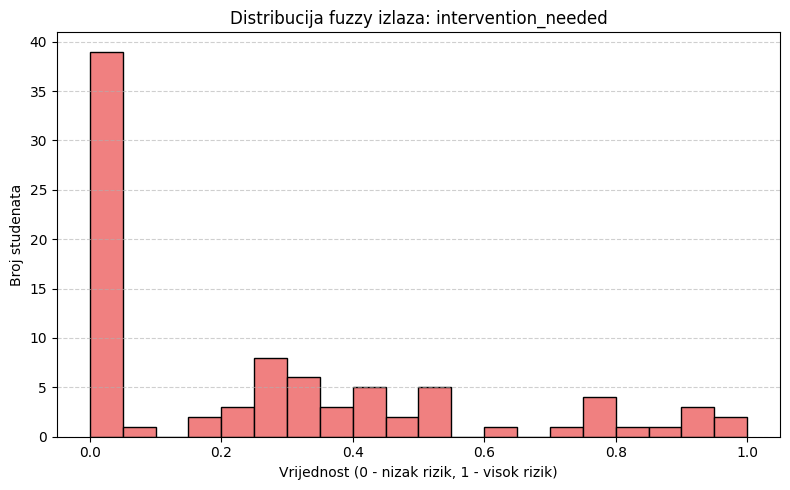

   average_sleep  financial_concerns  future_insecurity  isolation  anxiety  \
0       0.444444                0.75               0.25       0.00      0.0   
1       0.444444                0.00               0.75       0.50      0.5   
2       0.000000                0.50               0.00       0.50      0.5   
3       0.444444                0.75               0.50       1.00      1.0   
4       0.444444                0.25               0.75       0.75      1.0   

   depression  social_relationships  academic_pressure  intervention_needed  
0        0.25                  0.50               1.00             0.000000  
1        0.50                  0.50               0.75             0.027778  
2        0.25                  0.75               1.00             0.083333  
3        1.00                  0.00               0.75             0.611111  
4        1.00                  0.50               1.00             0.319444  


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Ispravka pogrešnog naziva kolone sa razmakom
data.rename(columns={'academic_workload ': 'academic_workload'}, inplace=True)

# Definisanje svih ulaznih varijabli koje se koriste za fuzzy sistem
input_vars = [
    'average_sleep', 'financial_concerns', 'future_insecurity',
    'isolation', 'anxiety', 'depression', 'social_relationships',
    'academic_pressure'
]

# Provjera postojanja svih definisanih ulaznih varijabli u podacima
assert all(var in data.columns for var in input_vars), "Nedostaje neka od ulaznih varijabli!"

# Uklanjanje svih redova koji sadrže NaN vrijednosti za relevantna polja
data_clean = data.dropna(subset=input_vars)

# Pretvaranje vrijednosti u numerički tip ako su slučajno stringovi
data_clean[input_vars] = data_clean[input_vars].apply(pd.to_numeric, errors='coerce')

# Normalizacija podataka u opsegu [0, 1] pomoću min-max skaliranja
df_normalized = data_clean.copy()
for var in input_vars:
    min_val = data_clean[var].min()
    max_val = data_clean[var].max()
    df_normalized[var] = (data_clean[var] - min_val) / (max_val - min_val)

# Generisanje "fiktivne" fuzzy izlazne varijable (intervention_needed)
df_normalized["intervention_needed"] = (
    df_normalized[['financial_concerns', 'future_insecurity', 'isolation',
                   'anxiety', 'depression', 'academic_pressure']].mean(axis=1) -
    df_normalized[['average_sleep', 'social_relationships']].mean(axis=1)
).clip(lower=0, upper=1)  # ograničavanje rezultata između 0 i 1

# Histogram prikaz raspodjele fuzzy izlaza
plt.figure(figsize=(8, 5))
plt.hist(df_normalized["intervention_needed"], bins=20, color='lightcoral', edgecolor='black')
plt.title("Distribucija fuzzy izlaza: intervention_needed")
plt.xlabel("Vrijednost (0 - nizak rizik, 1 - visok rizik)")
plt.ylabel("Broj studenata")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Mapiranje tekstualnih vrijednosti sna na numeričke prosječne vrijednosti
sleep_map = {
    "Less than 2 hrs": 1,
    "2-4 hrs": 3,
    "4-6 hrs": 5,
    "6-7 hrs": 6.5,
    "7-8 hrs": 7.5,
    "More than 8 hrs": 9
}

# Primjena mapiranja na originalni DataFrame
data['average_sleep_mapped'] = data['average_sleep'].map(sleep_map)

# Normalizacija nove kolone average_sleep_mapped i ažuriranje u df_normalized
min_sleep = data['average_sleep_mapped'].min()
max_sleep = data['average_sleep_mapped'].max()
df_normalized['average_sleep'] = (data['average_sleep_mapped'] - min_sleep) / (max_sleep - min_sleep)

# Ponovna izrada fuzzy izlaza sa ažuriranim vrijednostima spavanja
df_normalized["intervention_needed"] = (
    df_normalized[['financial_concerns', 'future_insecurity', 'isolation',
                   'anxiety', 'depression', 'academic_pressure']].mean(axis=1) -
    df_normalized[['average_sleep', 'social_relationships']].mean(axis=1)
).clip(lower=0, upper=1)

# Ispisujemo prvih 5 redova tabele sa ulazima i fuzzy izlazom
print(df_normalized[input_vars + ['intervention_needed']].head(5))


Graf pokazuje kako su raspoređene vrijednosti fuzzy izlaza *intervention_needed* za studente. Računato je koliko su negativni faktori (anksioznost, depresija, finansijske i školske brige) veći od pozitivnih (količina sna i kvalitet socijalnih odnosa). Vrijednosti su normalizirane od 0 (nema potrebe za intervencijom) do 1 (velika potreba). Većina studenata ima niske vrijednosti, ali manji broj pokazuje veći rizik i potrebu za podrškom.

###Pie chart za procjenu kategorije intervencije

In [ ]:
import plotly.express as px

kategorije_count = (
    final_output['intervention_category']
    .dropna()                              # izbacujemo NaN vrijednosti, ako ih ima
    .value_counts(normalize=True)          # računamo udio po kategoriji
    .mul(100)                              # u procentima
    .round(1)
    .rename_axis('kategorija')
    .reset_index(name='procenat')
)

# Kreiramo tzv. 'Pie chart'
fig = px.pie(
    kategorije_count,
    values='procenat',
    names='kategorija',
    title='Distribucija kategorija intervencije (u %): ',
    hole=0.35,
    color='kategorija',
    color_discrete_map={
        'minimalna': '#bde0fe',
        'umjerena': '#ffc8dd',
        'visoka': '#ff006e'
    }
)

fig.update_traces(textposition='inside', texttemplate='%{label}<br>%{value:.1f}%')
fig.show()

Graf prikazuje kako su studenti raspoređeni po kategorijama potrebe za intervencijom: *minimalna, umjerena i visoka*. Ove kategorije nisu određene oštrim granicama, već su rezultat rada fuzzy logičkog sistema koji koristi kombinaciju različitih, često nepreciznih i subjektivnih podataka, kao što su anksioznost, depresija, količina sna i društvena podrška, u skladu sa unaprijed definisanim pravilima.

Ono što je važno kod ovog grafa jeste da pokazuje kako fuzzy logika ne donosi jednostavne isključive odluke, koje su ili jedno ili drugo. Umjesto toga, dopušta da pojedinac može istovremeno djelimično pripadati više kategorija.

Nakon što sistem obradi sve podatke, daje se konačni rezultat koji se tumači kao dominantna kategorija. Zato je najviše studenata svrstano u srednju, umjerenu kategoriju što se tiče rizika — njihovo stanje nije zabrinjavajuće, ali sadrži dovoljno negativnih faktora da ne budu potpuno stabilni. Upravo ta mogućnost da se vidi ta nijansiranost i složenost stanja čini fuzzy pristup posebno korisnim u oblasti mentalnog zdravlja.

Uključivanjem ovog grafa dobijamo jasan pregled kako su rizična stanja raspoređena unutar grupe studenata.

###3D Scatter plot za vizualizaciju odnosa između depresije, izolacije i fuzzy izlaza

In [ ]:
import plotly.express as px

# Osiguravamo da su ključne kolone numeričkog tipa
final_output['depression'] = pd.to_numeric(final_output['depression'], errors='coerce')
final_output['isolation'] = pd.to_numeric(final_output['isolation'], errors='coerce')
final_output['intervention_score'] = pd.to_numeric(final_output['intervention_score'], errors='coerce')

# Kreiramo 3D scatter plot za vizualizaciju odnosa između depresije, izolacije i fuzzy izlaza
fig = px.scatter_3d(
    final_output,
    x='depression',                  # Osa X: nivo depresije
    y='isolation',                   # Osa Y: osjećaj izolovanosti
    z='intervention_score',          # Osa Z: rezultat fuzzy procjene
    color='intervention_category',   # Bojenje prema kategoriji potrebe za intervencijom
    color_discrete_map={             # Definisane boje za svaku kategoriju
        'minimalna': '#bde0fe',      # Svijetloplava za minimalnu
        'umjerena': '#ffc8dd',       # Svijetloroza za umjerenu
        'visoka': '#ff006e'          # Tamnoroza za visoku
    },
    title='3D prikaz: Depression, Isolation i Intervention Score'
)

# Podešavamo izgled markera u scatter plot-u
fig.update_traces(marker=dict(size=5, opacity=0.7))

fig.show()

U ovom dijelu smo koristili 3D Scatter Plot kako bismo prikazali i ustanovili jačinu veze između izlazne fuzzy varijable i ulaznih varijabli 'depression' - koja prikazuje nivo osjećaja depresije kod studenata i 'isolation' - predstavlja osjećaj izolovanosti i/ili potrebu za izolacijom kod studenata. Ima smisla ispitivati ove dvije ulazne varijable i njihov utjecaj na izlaznu varijablu u istom grafiku, kako ove dvije varijable generalno imaju visoku međusobnu korelaciju.

Generalni zaključak iz grafika je da ulazne varijable djeluju na izlaznu varijablu kako je i bilo očekivano. Kako nivo depresije i/ili izolacije raste, može se čak reći i da je pravilo (iako ima izuzetaka), da raste i potreba za intervencijom. Ovo možemo potvrditi posmatrajući i analizirajući detaljnije grafik, tamnoroze tačkice (koje predstavljaju visoku potrebu za intervencijom) nalaze se u dijelu grafa gdje je vrijednost ulaznih varijabli 4 ili 5 (visoko). S druge strane, kod plavih tačkica koje predstavljaju studente sa niskom potrebom za intervencijom, imamo više 'nepravilnosti', ali opet možemo primijetiti da se najveći broj ovih instanci nalazi upravu u području gdje su niske vrijednosti ulaznih varijabli.

###Radar graf za prikaz psihološkog profila jednog studenta

In [ ]:
import plotly.graph_objects as go
import skfuzzy.control as ctrl

idx = 5  # ili bilo koji red koji želimo ispitati, promjenom ovog broja prelazimo na profil drugog studenta i graf se mijenja
row = input_variables.loc[idx]

kategorije = [
    'average_sleep', 'financial_concerns', 'future_insecurity',
    'isolation', 'anxiety', 'depression',
    'social_relationships', 'academic_pressure'
]

# Radar graf
fig = go.Figure()
fig.add_trace(go.Scatterpolar(
    r=row[kategorije].tolist(),
    theta=kategorije,
    fill='toself',
    name=f'Student {idx}'
))
fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 10])),
    showlegend=False,
    title='Profil ulaznih varijabli jedne instance u datasetu (jednog studenta)'
)
fig.show()

# Izračun fuzzy izlaza
simulacija = ctrl.ControlSystemSimulation(intervention_ctrl)

# Postavljamo ulaze iz odabranog reda
for var in kategorije:
    simulacija.input[var] = row[var]

simulacija.compute()
interventionScore = simulacija.output['intervention_needed']

print(f"\n Potreba za intervencijom za studenta {idx} (skala 0-100): {interventionScore:.2f}")



 Potreba za intervencijom za studenta 5 (skala 0-100): 65.71


Ovaj prikazani graf daje sliku o *psihološkom profilu jednog studenta* na osnovu svih ulaznih varijabli koje koristi naš fuzzy sistem, prethodno definisanih pri pripremi podataka. Svaka osa na grafu predstavlja jedan od faktora koji utiču na mentalno stanje, poput sna, anksioznosti, depresije, izolacije i slično. Ova vizualizacija nam daje jasniju sliku o tome kako kombinacija faktora specifičnih za jednog pojedinca oblikuje konačnu fuzzy procjenu potrebe za intervencijom.

Cilj uključivanja ovog grafa u projekat jeste da pokaže *direktnu vezu između individualnih ulaza i fuzzy izlaza*. Na osnovu rasporeda i intenziteta faktora u profilu, fuzzy logički sistem izračunava numeričku vrijednost intervencijskog rizika.

Osim što ovaj graf pomaže razumijevanju rada fuzzy sistema, on ima i potencijalnu primjenu u kontekstu savjetovanja i podrške studentima. Ovaj vizuelni prikaz je moguće koristiti kako bi brzo i efikasno identifikovali dominantne rizične faktore kod pojedinca i planirali odgovarajuću vrstu podrške.

###Radar grad za prikaz psihološkog profila više studenata

In [ ]:
import plotly.graph_objects as go

#Definišemo kategorije
kategorije = [
    'average_sleep', 'financial_concerns', 'future_insecurity',
    'isolation', 'anxiety', 'depression',
    'social_relationships', 'academic_pressure'
]

# Biramo po jednog predstavnika iz svake intervencijske kategorije
uzorci = {}
for kategorija in ['minimalna', 'umjerena', 'visoka']:
    red = final_output[final_output['intervention_category'] == kategorija].iloc[0]
    uzorci[kategorija] = red

# Kreiramo radar
fig = go.Figure()

for kategorija, red in uzorci.items():
    fig.add_trace(go.Scatterpolar(
        r=red[kategorije].tolist(),
        theta=kategorije,
        fill='toself',
        name=kategorija
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 10])),
    showlegend=True,
    title='Radar: Poređenje 3 studenta po rizičnim faktorima'
)
fig.show()


Graf prikazuje poređenje po jednog predstavnika iz svake fuzzy kategorije potrebe za intervencijom koju smo definisali odnosno po predstavnik iz  minimalne, umjerene i visoke kategorije potrebe za intervencijom. U grafiku se  *poredi psihološki profil odabranih studenata* i prikazuje se kroz sve relevantne ulazne varijable kao na prethodnom grafu. Na ovaj način možemo *direktno uporediti intenzitet rizičnih faktora kod studenata različitih kategorija*.

Vidljivo je da studenti koji pripadaju višim kategorijama intervencije imaju izraženije vrijednosti negativnih faktora poput anksioznosti, depresije, izolacije ili problema sa snom. Ovakav uzorak ponašanja potvrđuje da naš fuzzy sistem ispravno reaguje na promjene u ulaznim podacima i mapira psihološke profile na odgovarajuće nivoe intervencijske potrebe.


###t-SNE klasterizacija studenata

In [ ]:
from sklearn.manifold import TSNE
from sklearn.impute import SimpleImputer
import plotly.express as px
import pandas as pd

# Mapiranje varijable sna koja je tipa string na brojeve
sleep_map = {
    '<4 hrs': 3,
    '4-6 hrs': 5,
    '6-8 hrs': 7,
    '8-10 hrs': 9,
    '10+ hrs': 11
}

final_output['average_sleep_num'] = final_output['average_sleep'].map(sleep_map)

# Odabir ulaznih varijabli za t-SNE
kategorije_num = [
    'average_sleep_num', 'financial_concerns', 'future_insecurity',
    'isolation', 'anxiety', 'depression',
    'social_relationships', 'academic_pressure'
]

X = final_output[kategorije_num]

# Imputacija (zamjena NaN sa srednjom vrijednosti)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X_imputed)

# Dodavanje natrag u DataFrame
final_output['TSNE1'] = X_tsne[:, 0]
final_output['TSNE2'] = X_tsne[:, 1]

# Vizualizacija
fig = px.scatter(
    final_output,
    x='TSNE1',
    y='TSNE2',
    color='intervention_category',
    title='t-SNE klasterizacija studenata',
    color_discrete_map={
        'minimalna': '#bde0fe',
        'umjerena': '#ffc8dd',
        'visoka': '#ff006e'
    },
    hover_data=['average_sleep', 'depression', 'anxiety']
)

fig.update_traces(marker=dict(size=6, opacity=0.7))
fig.show()


U ovom dijelu je korišten tzv.* t-SNE algoritam* za *utvrđivanje veze između ulaznih varijabli i izlazne fuzzy varijable* i dati graf prikazuje rezultate kojim su studenti mapirani u dvodimenzionalni prostor na osnovu svojih psiholoških karakteristika i ustanovljenog rizika za mentalno zdravlje. t-SNE je nelinearna metoda za redukciju dimenzionalnosti koja omogućava da studenti sličnih profila budu vizualno grupisani bliže jedni drugima.

Boje na grafu predstavljaju fuzzy kategorije potrebe za intervencijom koje je odredio naš fuzzy sistem (minimalna, umjerena i visoka). U ovom slučaju za prikaz minimalne potrebe za intervencijom korištena je svijetloplava boja, a za umjereno visoku svijetlo- i tamnoroza respektivno. Iako t-SNE ne koristi te kategorije prilikom grupisanja, jasno se vidi tendencija da se studenti sa sličnim fuzzy ishodima grupišu na sličnim dijelovima grafa. To potvrđuje da fuzzy sistem dosljedno klasifikuje slične profile i ponaša se u skladu s očekivanjima. Ovaj graf time služi kao dodatna *validacija ispravnosti fuzzy logike*, jer pokazuje da je raspodjela izlaza u skladu sa predviđenim ponašanjem.


---
##6. Zaključak i refleksija
---

Korištenjem stvarnog skupa podataka o mentalnom zdravlju studenata s platforme Kaggle, razvile smo fuzzy logički sistem koji procjenjuje vjerovatnoću postojanja mentalnih poteškoća na osnovu više ulaznih faktora. Ovaj pristup omogućio nam je da se neprecizni, subjektivni i međusobno zavisni podaci poput nivoa stresa, osjećaja izolovanosti, problema sa spavanjem i zadovoljstva životom, analiziraju fleksibilnije nego u klasičnim determinističkim modelima.

Fuzzy kontroler se u ovom kontekstu pokazao kao izuzetno korisno sredstvo za rješavanje stvarnog problema iz života: rane identifikacije studenata koji su u riziku od mentalnih poteškoća. Umjesto da koristi striktne granične vrijednosti, fuzzy sistem radi s neizrazitim (fuzzy) skupovima i lingvističkim varijablama kao što su “visok stres”, “loš san” ili “nisko zadovoljstvo”, što mu omogućava da približno oponaša način na koji ljudi procjenjuju psihičko stanje.

Posebna prednost ovog pristupa ogleda se u tome što koristimo stvarne podatke, čime se poboljšava tačnost i korisnost sistema. Umjesto teorijskih pretpostavki, pravila i skupovi su prilagođeni obrascima koji su uočeni u podacima studenata iz različitih konteksta, što sistem čini primjenjivim u praksi. Iako sistem nije dijagnostički alat, može poslužiti kao podrška savjetnicima i obrazovnim institucijama u ranoj identifikaciji rizičnih slučajeva i boljoj prevenciji.

U konačnici, cilj ovog projekta je da pokaže da fuzzy logika, uz podršku stvarnih podataka, može ponuditi funkcionalan i intuitivan način za rješavanje kompleksnih problema koji uključuju subjektivne i emocionalne komponente — kao što je upravo mentalno zdravlje studenata.
